URČETE P PRO KTERÉ PLATÍ

INTEGRÁL od 0 do P: (INTEGRÁL od 0 do 2pí) uvnitč: e**-alpha*pí * sin(x) dx          target = 1.31848

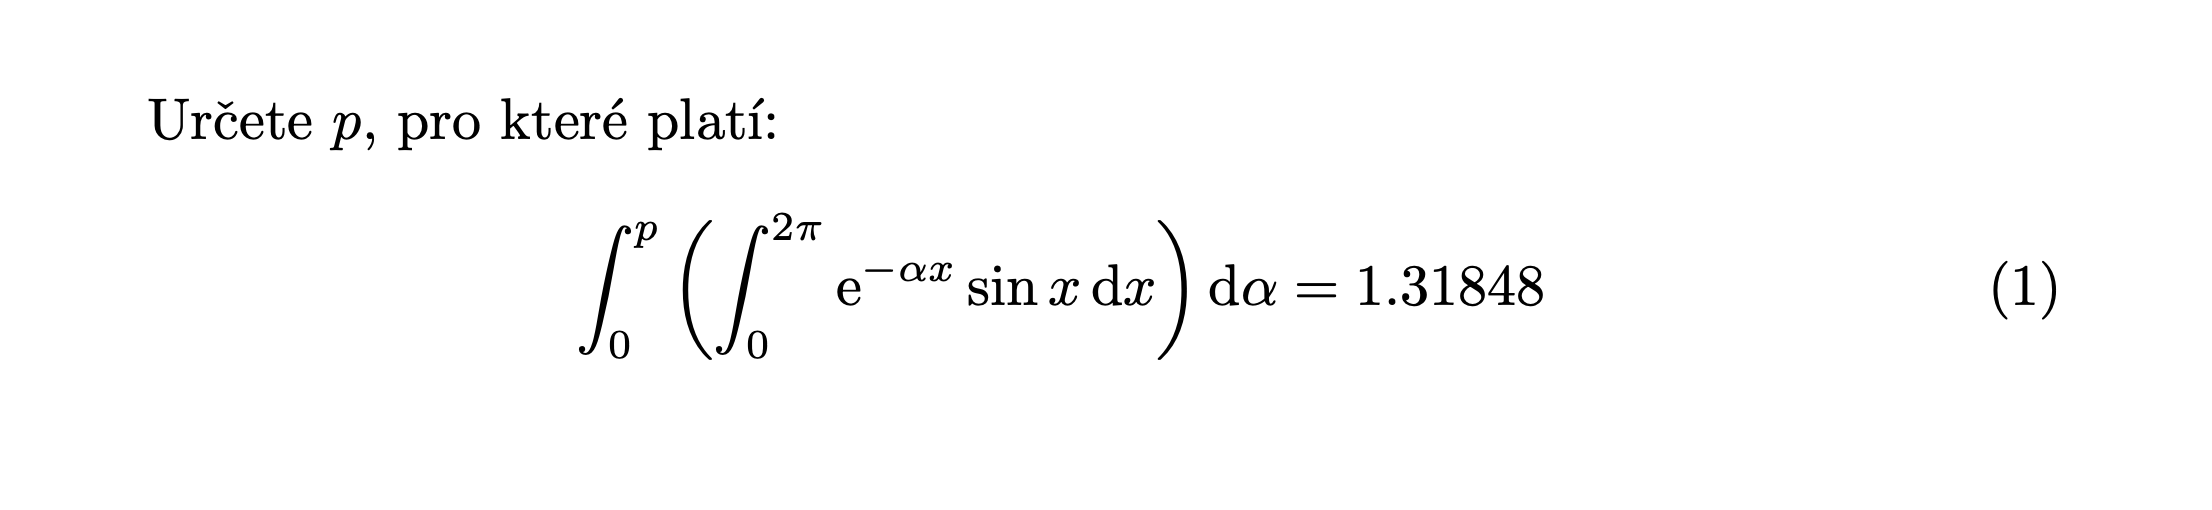


In [60]:
import math
def simpson_rule(f, a, b, n):
    """
    Numerický výpočet integrálu pomocí Simpsonova pravidla.
    
    :param f: Integrovaná funkce
    :param a: Dolní mez
    :param b: Horní mez
    :param n: Počet dělení (musí být sudé a >= 2)
    :return: Přibližná hodnota integrálu
    """
    # Simpson vyžaduje sudý počet intervalů (n+1 bodů)
    if n < 2 or n % 2 != 0:
        print("Chyba: n musí být sudé a >= 2.")
        return None

    h = (b - a) / n
    # Začneme součtem krajních hodnot f(a) + f(b)
    total_sum = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        # Body v lichých pozicích se násobí 4, v sudých 2
        if i % 2 == 0:
            total_sum += 2 * f(x)
        else:
            total_sum += 4 * f(x)

    # Konečný vzorec: (h/3) * (f(a) + 4*f(x1) + 2*f(x2) + 4*f(x3) + ... + f(b))
    approximation = (h / 3) * total_sum
    return approximation



def bisection(f, a, b, tol, max_iter, verbose=False):
    """
    Numerické hledání kořene funkce pomocí metody půlení intervalu.

    :param f: Funkce, jejíž kořen hledáme
    :param a: Levá mez intervalu
    :param b: Pravá mez intervalu
    :param tol: Tolerance (přesnost)
    :param max_iter: Maximální počet iterací
    :param verbose: Vypisovat průběh iterací (default False)
    :return: Kořen funkce nebo None, pokud metoda selže
    """
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        print("Chyba: Žádná změna znaménka, kořen v intervalu nelze zaručit.")
        return None

    c = a
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if verbose:
            print(f"Iterace {i+1:3d}: c = {c:.10f}, f(c) = {fc:.4e}, délka intervalu = {(b-a)/2:.4e}")

        if abs(fc) < tol or (b - a) / 2 < tol:
            if verbose:
                print(f"Konvergoval v iteraci {i+1}.")
            return c

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    print("Chyba: Metoda neskonvergovala.")
    return None

# Příklad použití:
# root = bisection(lambda x: x**2 - 4, 0, 5, 1e-6, 100)
# print(f"Kořen je: {root}")

#udelame si vnitrni integral .. bacha !  2 proměnné musime to udělat fikaně

def vnitrni_integral(alpha):

    vnitr_fun = lambda x: math.e**(-alpha*x)*math.sin(x)
    return simpson_rule(vnitr_fun,0,2*math.pi,100)


def vnejsi_integral(p):
    return simpson_rule(vnitrni_integral,0,p,100)

#vnejsi_integral(2)

#UKAZU SKVOROVI, JAK JSME NAŠEL POZICI KDE SE MĚNÍ ZNAMÁNKO DÍKY ZNALOSTI TOHO CO HLEDÁME : ) 

for p in range(-20, 20):
    print(f"p={p}, vnejsi_integral(p)-0.13148 = {vnejsi_integral(p) - 1.31848}")



def vysledek(a,b):
    target = 1.31848
    fukce = lambda p: vnejsi_integral(p) - target
    p = bisection(fukce,a,b,1e-8,100,verbose=True)
    vnejsi_integral(p)
    print(f"p = {p}")             # :.10f jen zkracuje výsledek jakoby   
    print(f"ověření: vnejsi(p) = {vnejsi_integral(p)}")   #:.6f

#vysledek(-1,1)
#vysledek(-5,-0.01)

vysledek(1,12)



p=-20, vnejsi_integral(p)-0.13148 = 1.4863042771481811e+51
p=-19, vnejsi_integral(p)-0.13148 = 3.087242079926795e+48
p=-18, vnejsi_integral(p)-0.13148 = 6.446255359166126e+45
p=-17, vnejsi_integral(p)-0.13148 = 1.3539514209451044e+43
p=-16, vnejsi_integral(p)-0.13148 = 2.862817371171486e+40
p=-15, vnejsi_integral(p)-0.13148 = 6.099295572683332e+37
p=-14, vnejsi_integral(p)-0.13148 = 1.310820614891929e+35
p=-13, vnejsi_integral(p)-0.13148 = 2.845585813168834e+32
p=-12, vnejsi_integral(p)-0.13148 = 6.250149592131303e+29
p=-11, vnejsi_integral(p)-0.13148 = 1.391906471187243e+27
p=-10, vnejsi_integral(p)-0.13148 = 3.151339668126511e+24
p=-9, vnejsi_integral(p)-0.13148 = 7.278944583701592e+21
p=-8, vnejsi_integral(p)-0.13148 = 1.7233463767149185e+19
p=-7, vnejsi_integral(p)-0.13148 = 4.209550452158895e+16
p=-6, vnejsi_integral(p)-0.13148 = 107083559503454.3
p=-5, vnejsi_integral(p)-0.13148 = 287706203409.64075
p=-4, vnejsi_integral(p)-0.13148 = 834881729.281153
p=-3, vnejsi_integral(p)-0.13

In [58]:
vnejsi_integral(9.99999)

1.3182876063038418

In [61]:

def midpoint_rule(f, a, b, n):
    """
    Numerický výpočet určitého integrálu funkce f na intervalu [a, b].
    
    :param f: Integrovaná funkce
    :param a: Dolní mez
    :param b: Horní mez
    :param n: Počet dělení (obdélníků)
    :return: Přibližná hodnota integrálu
    """
    if n < 1:
        print("Chyba: n musí být >= 1.")
        return None

    # Šířka jednoho obdélníku
    h = (b - a) / n
    total_sum = 0.0
    
    # Procházíme n podintervalů
    for i in range(n):
        # Výpočet středu aktuálního obdélníku
        midpoint = a + (i + 0.5) * h
        total_sum += f(midpoint)
    
    # Celkový obsah je šířka krát součet výšek
    approximation = h * total_sum
    return approximation



def bisection(f, a, b, tol, max_iter, verbose=False):
    """
    Numerické hledání kořene funkce pomocí metody půlení intervalu.

    :param f: Funkce, jejíž kořen hledáme
    :param a: Levá mez intervalu
    :param b: Pravá mez intervalu
    :param tol: Tolerance (přesnost)
    :param max_iter: Maximální počet iterací
    :param verbose: Vypisovat průběh iterací (default False)
    :return: Kořen funkce nebo None, pokud metoda selže
    """
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        print("Chyba: Žádná změna znaménka, kořen v intervalu nelze zaručit.")
        return None

    c = a
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        if verbose:
            print(f"Iterace {i+1:3d}: c = {c:.10f}, f(c) = {fc:.4e}, délka intervalu = {(b-a)/2:.4e}")

        if abs(fc) < tol or (b - a) / 2 < tol:
            if verbose:
                print(f"Konvergoval v iteraci {i+1}.")
            return c

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    print("Chyba: Metoda neskonvergovala.")
    return None

# Příklad použití:
# root = bisection(lambda x: x**2 - 4, 0, 5, 1e-6, 100)
# print(f"Kořen je: {root}")

#udelame si vnitrni integral .. bacha !  2 proměnné musime to udělat fikaně

def vnitrni_integral(alpha):

    vnitr_fun = lambda x: math.e**(-alpha*x)*math.sin(x)
    return midpoint_rule(vnitr_fun,0,2*math.pi,100)


def vnejsi_integral(p):
    return midpoint_rule(vnitrni_integral,0,p,100)


#vnejsi_integral(2)


#UKAZU SKVOROVI, JAK JSME NAŠEL POZICI KDE SE MĚNÍ ZNAMÁNKO DÍKY ZNALOSTI TOHO CO HLEDÁME : ) 

for p in range(-20, 20):
    print(f"p={p}, vnejsi_integral(p)-0.13148 = {vnejsi_integral(p) - 1.31848}")





def vysledek(a,b):
    target = 1.31848
    fukce = lambda p: vnejsi_integral(p) - target
    p = bisection(fukce,a,b,1e-8,100,verbose=True)
    vnejsi_integral(p)
    print(f"p = {p}")             # :.10f jen zkracuje výsledek jakoby   
    print(f"ověření: vnejsi(p) = {vnejsi_integral(p)}")   #:.6f

vysledek(1,12)



p=-20, vnejsi_integral(p)-0.13148 = 1.5041913376482453e+51
p=-19, vnejsi_integral(p)-0.13148 = 3.119146935377531e+48
p=-18, vnejsi_integral(p)-0.13148 = 6.50289811375001e+45
p=-17, vnejsi_integral(p)-0.13148 = 1.3639611407896775e+43
p=-16, vnejsi_integral(p)-0.13148 = 2.880427906058837e+40
p=-15, vnejsi_integral(p)-0.13148 = 6.130154071921216e+37
p=-14, vnejsi_integral(p)-0.13148 = 1.3162101431648821e+35
p=-13, vnejsi_integral(p)-0.13148 = 2.8549795015714195e+32
p=-12, vnejsi_integral(p)-0.13148 = 6.266520809346529e+29
p=-11, vnejsi_integral(p)-0.13148 = 1.394767938971758e+27
p=-10, vnejsi_integral(p)-0.13148 = 3.1563781472946956e+24
p=-9, vnejsi_integral(p)-0.13148 = 7.287939632396966e+21
p=-8, vnejsi_integral(p)-0.13148 = 1.7249890492485773e+19
p=-7, vnejsi_integral(p)-0.13148 = 4.212654827990208e+16
p=-6, vnejsi_integral(p)-0.13148 = 107145140190833.86
p=-5, vnejsi_integral(p)-0.13148 = 287836553049.43854
p=-4, vnejsi_integral(p)-0.13148 = 835181797.1302723
p=-3, vnejsi_integral(p)-